In [2]:
import numpy as np
import os
import cv2
from thorlabs_tsi_sdk.tl_camera import TLCameraSDK, OPERATION_MODE
import matplotlib.pyplot as plt

try:
    # if on Windows, use the provided setup script to add the DLLs folder to the PATH
    from windows_setup import configure_path
    configure_path()
except ImportError:
    configure_path = None

with TLCameraSDK() as sdk:
    available_cameras = sdk.discover_available_cameras()
    if len(available_cameras) < 1:
        print("no cameras detected")

    with sdk.open_camera(available_cameras[1]) as camera:
        camera.exposure_time_us = 10000  # set exposure to 11 ms
        camera.frames_per_trigger_zero_for_unlimited = 0  # start camera in continuous mode
        camera.image_poll_timeout_ms = 1000  # 1 second polling timeout

        camera.arm(2)

        camera.issue_software_trigger()

        frame = camera.get_pending_frame_or_null()
        if frame is not None:
            print("frame #{} received!".format(frame.frame_count))
            frame.image_buffer
            image_buffer_copy = np.copy(frame.image_buffer)
            numpy_shaped_image = image_buffer_copy.reshape(camera.image_height_pixels, camera.image_width_pixels)
            print(numpy_shaped_image)
            nd_image_array = np.full((camera.image_height_pixels, camera.image_width_pixels, 3), 0, dtype=np.uint8)
            nd_image_array[:,:,0] = numpy_shaped_image
            nd_image_array[:,:,1] = numpy_shaped_image
            nd_image_array[:,:,2] = numpy_shaped_image
            
            # cv2.imshow("Image From TSI Cam", numpy_shaped_image)
        else:
            print("Unable to acquire image, program exiting...")
            exit()
            
        cv2.waitKey(0)
        camera.disarm()

#  Because we are using the 'with' statement context-manager, disposal has been taken care of.

print("program completed")


frame #1 received!
[[ 6 10  4 ...  4  4  3]
 [ 4 10  9 ...  6  3  3]
 [ 7  6  6 ...  5  7  5]
 ...
 [ 2  1  1 ...  3  2  2]
 [ 3  2  3 ...  2  3  2]
 [ 3  2  1 ...  3  2  2]]
program completed


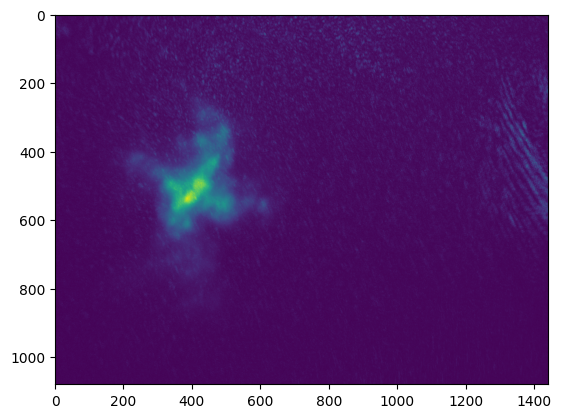

In [12]:
import matplotlib.pyplot as plt

# print(numpy_shaped_image)
plt.imshow()

In [ ]:
from pathlib import Path
from typing import Optional, Union

import numpy as np
import cv2

try:
    # If you are on Windows and using the relative-path DLL setup script
    from windows_setup import configure_path
    configure_path()
except ImportError:
    pass

from thorlabs_tsi_sdk.tl_camera import TLCameraSDK


class ThorCamManager:
    """Utility manager for Thorlabs camera discovery."""

    @staticmethod
    def list_available_serial_numbers() -> list[str]:
        """Return all available Thorlabs camera serial numbers."""
        with TLCameraSDK() as sdk:
            return list(sdk.discover_available_cameras())


class ThorCam:
    """Wrapper class for a Thorlabs TSI camera with lower-overhead acquisition paths."""

    def __init__(self, camera_serial: Optional[str] = None):
        self.sdk = None
        self.camera = None
        self.camera_serial = camera_serial
        self.armed = False
        self._arm_buffer_frame_count = None
        self._streaming = False
        self._settings_cache = {
            "exposure_time_us": None,
            "image_poll_timeout_ms": None,
            "frames_per_trigger": None,
        }

        self.sdk = TLCameraSDK()
        available_cameras = list(self.sdk.discover_available_cameras())

        if not available_cameras:
            self.sdk.dispose()
            self.sdk = None
            raise RuntimeError("No Thorlabs cameras detected.")

        if self.camera_serial is None:
            self.sdk.dispose()
            self.sdk = None
            raise ValueError(
                "camera_serial is required. Please input the correct camera serial number. "
                f"Detected camera serial number(s): {available_cameras}"
            )

        if self.camera_serial not in available_cameras:
            self.sdk.dispose()
            self.sdk = None
            raise ValueError(
                f"camera_serial={self.camera_serial!r} was not found. "
                f"Detected camera serial number(s): {available_cameras}"
            )

        self.camera = self.sdk.open_camera(self.camera_serial)

    def arm(self, buffer_frame_count: int = 2) -> None:
        """Arm the camera before acquisition."""
        self._ensure_open()

        if self.armed and self._arm_buffer_frame_count == buffer_frame_count:
            return

        if self.armed:
            self.disarm()

        self.camera.arm(buffer_frame_count)
        self.armed = True
        self._arm_buffer_frame_count = buffer_frame_count

    def disarm(self) -> None:
        """Disarm the camera."""
        if self.camera is not None and self.armed:
            self.camera.disarm()
            self.armed = False
            self._arm_buffer_frame_count = None
            self._streaming = False

    def close(self) -> None:
        """Close camera and dispose SDK."""
        try:
            self.disarm()
        finally:
            if self.camera is not None:
                self.camera.dispose()
                self.camera = None

            if self.sdk is not None:
                self.sdk.dispose()
                self.sdk = None

    def get_camera_info(self) -> dict:
        """Return basic camera information."""
        self._ensure_open()
        return {
            "serial_number": self.camera_serial,
            "image_width_pixels": self.camera.image_width_pixels,
            "image_height_pixels": self.camera.image_height_pixels,
            "exposure_time_us": self.camera.exposure_time_us,
            "image_poll_timeout_ms": self.camera.image_poll_timeout_ms,
            "armed": self.armed,
            "streaming": self._streaming,
        }

    def _apply_acquisition_settings(
        self,
        exposure_time_us: int,
        image_poll_timeout_ms: int,
        frames_per_trigger: int,
    ) -> None:
        self._ensure_open()

        new_settings = {
            "exposure_time_us": exposure_time_us,
            "image_poll_timeout_ms": image_poll_timeout_ms,
            "frames_per_trigger": frames_per_trigger,
        }
        settings_changed = any(
            self._settings_cache[key] != value for key, value in new_settings.items()
        )

        if settings_changed and self.armed:
            self.disarm()

        if self._settings_cache["exposure_time_us"] != exposure_time_us:
            self.camera.exposure_time_us = exposure_time_us
            self._settings_cache["exposure_time_us"] = exposure_time_us

        if self._settings_cache["image_poll_timeout_ms"] != image_poll_timeout_ms:
            self.camera.image_poll_timeout_ms = image_poll_timeout_ms
            self._settings_cache["image_poll_timeout_ms"] = image_poll_timeout_ms

        if self._settings_cache["frames_per_trigger"] != frames_per_trigger:
            self.camera.frames_per_trigger_zero_for_unlimited = frames_per_trigger
            self._settings_cache["frames_per_trigger"] = frames_per_trigger

    def _poll_frame(self, copy: bool = True) -> Optional[np.ndarray]:
        self._ensure_open()
        frame = self.camera.get_pending_frame_or_null()
        if frame is None:
            return None

        image_buffer = np.copy(frame.image_buffer) if copy else frame.image_buffer
        return image_buffer.reshape(
            self.camera.image_height_pixels,
            self.camera.image_width_pixels,
        )

    def _capture_frame(
        self,
        exposure_time_us: int,
        image_poll_timeout_ms: int,
        frames_per_trigger: int,
        buffer_frame_count: int,
    ) -> np.ndarray:
        self._apply_acquisition_settings(
            exposure_time_us=exposure_time_us,
            image_poll_timeout_ms=image_poll_timeout_ms,
            frames_per_trigger=frames_per_trigger,
        )
        self.arm(buffer_frame_count=buffer_frame_count)
        self.camera.issue_software_trigger()

        try:
            image = self._poll_frame(copy=True)
            if image is None:
                raise RuntimeError("Failed to acquire frame: no frame received before timeout.")
            return image
        finally:
            self.disarm()

    def start_continuous_acquisition(
        self,
        exposure_time_us: int = 10000,
        image_poll_timeout_ms: int = 1000,
        buffer_frame_count: int = 2,
    ) -> None:
        """Arm once and trigger once so subsequent calls only need to poll frames."""
        self._apply_acquisition_settings(
            exposure_time_us=exposure_time_us,
            image_poll_timeout_ms=image_poll_timeout_ms,
            frames_per_trigger=0,
        )
        self.arm(buffer_frame_count=buffer_frame_count)
        self.camera.issue_software_trigger()
        self._streaming = True

    def stop_continuous_acquisition(self) -> None:
        """Stop continuous acquisition if it is running."""
        self.disarm()

    def get_latest_frame(self, normalize_for_display: bool = False) -> Optional[np.ndarray]:
        """Return the next available frame from an active continuous acquisition."""
        if not self._streaming:
            raise RuntimeError("Continuous acquisition is not active. Call start_continuous_acquisition() first.")

        image = self._poll_frame(copy=True)
        if image is None:
            return None

        if normalize_for_display:
            return self._to_display_image(image)

        return image

    def grab_single_frame(
        self,
        exposure_time_us: int = 10000,
        image_poll_timeout_ms: int = 1000,
        frames_per_trigger: int = 1,
        buffer_frame_count: int = 2,
        normalize_for_display: bool = False,
    ) -> np.ndarray:
        """Acquire one frame with per-capture camera parameters."""
        image = self._capture_frame(
            exposure_time_us=exposure_time_us,
            image_poll_timeout_ms=image_poll_timeout_ms,
            frames_per_trigger=frames_per_trigger,
            buffer_frame_count=buffer_frame_count,
        )

        if normalize_for_display:
            return self._to_display_image(image)

        return image

    def snap(self, normalize_for_display: bool = False) -> np.ndarray:
        """Backward-compatible alias for grab_single_frame."""
        return self.grab_single_frame(normalize_for_display=normalize_for_display)

    def show_frame(
        self,
        frame: np.ndarray,
        window_name: str = "Thorlabs Camera",
        wait_key: int = 0,
    ) -> None:
        """Display a frame using OpenCV."""
        display_image = frame if frame.dtype == np.uint8 else self._to_display_image(frame)
        cv2.imshow(window_name, display_image)
        cv2.waitKey(wait_key)

    def live_preview(
        self,
        exposure_time_us: int = 10000,
        image_poll_timeout_ms: int = 1000,
        buffer_frame_count: int = 2,
        window_name: str = "Thorlabs Live Preview",
        normalize_for_display: bool = True,
    ) -> None:
        """Show a live preview until the user presses 'q' or ESC."""
        print("Live preview started. Press 'q' or ESC to quit.")

        self.start_continuous_acquisition(
            exposure_time_us=exposure_time_us,
            image_poll_timeout_ms=image_poll_timeout_ms,
            buffer_frame_count=buffer_frame_count,
        )

        try:
            while True:
                image = self.get_latest_frame(normalize_for_display=normalize_for_display)
                if image is not None:
                    cv2.imshow(window_name, image)

                key = cv2.waitKey(1) & 0xFF
                if key == ord("q") or key == 27:
                    break

        finally:
            self.stop_continuous_acquisition()
            try:
                cv2.destroyWindow(window_name)
            except cv2.error:
                pass

    def save_frame(
        self,
        filepath: Union[str, Path],
        frame: np.ndarray,
        normalize_if_needed: bool = True,
    ) -> Path:
        """Save a frame to disk."""
        filepath = Path(filepath)
        filepath.parent.mkdir(parents=True, exist_ok=True)

        image_to_save = frame
        if frame.dtype != np.uint8 and normalize_if_needed:
            image_to_save = self._to_display_image(frame)

        success = cv2.imwrite(str(filepath), image_to_save)
        if not success:
            raise IOError(f"Failed to save image to: {filepath}")

        return filepath

    def snap_and_save(
        self,
        filepath: Union[str, Path],
        normalize_for_display: bool = False,
        normalize_if_needed_for_save: bool = True,
    ) -> Path:
        """Acquire one frame and save it."""
        frame = self.snap(normalize_for_display=normalize_for_display)
        return self.save_frame(
            filepath=filepath,
            frame=frame,
            normalize_if_needed=normalize_if_needed_for_save,
        )

    @staticmethod
    def _to_display_image(image: np.ndarray) -> np.ndarray:
        """Convert raw image to an 8-bit image for display or saving."""
        display_image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
        return display_image.astype(np.uint8)

    def _ensure_open(self) -> None:
        if self.camera is None or self.sdk is None:
            raise RuntimeError("Camera is closed. Create a new ThorCam instance before acquiring frames.")

    def __enter__(self):
        self._ensure_open()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.close()